## E1: Does cell pairing with PerturbOT improves interspecies cell type prediction accuracy?

**Started:** October 6, 2025

**Last updated:** October 21, 2025

**Research question:** Does prior alignment (pairings) of cells within across species using Perturb-OT improve cell type prediction accuracy of a MLP+kNN approach?

**Hypothesis:** Yes, because pairwise correspondences will enable better supervised learning of the relationships between genes across species.

**Conclusion:** Using a Perturb-OT "get_coupling_egw_labels_ott" Sinkhorn entropy parameter of ~1e-8 when generating point-to-point pairings of mouse and human cells results in significantly higher cell type prediction accuracy.

**Potential Next Steps:** Investigate whether pre-pairing also results in closer distances between predicted and actual points.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc
from pytorch_helpers import fit_mlp
import perturbot
from perturbot.match import get_coupling_egw_labels_ott
from perturbot.predict import train_mlp

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text fro

In [2]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [3]:
human_adatas = top_n_organisms_from_species(human_dir, 8, 'human')

In [4]:
mouse_adatas = top_n_organisms_from_species(mouse_dir, 8, 'mouse')

In [5]:
all_adatas = mouse_adatas + human_adatas
pairs = [(i,i+8) for i in range(8)]

In [6]:
# Gather data
n_samples = 2000
a1_full, a2_full = sample_equal_cell_types(all_adatas[0], all_adatas[8], n_samples)

In [7]:
a1_train, a1_test, a2_train, a2_test = test_train_split_adata(a1_full, a2_full, train_ratio=0.8)

In [8]:
X_dict, Y_dict, X_full_dict, Y_full_dict, X_index_dict, Y_index_dict = create_label_to_sample_dicts(a1_train, a2_train)

In [9]:
# Learn matching in the latent space
T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict)) # Other get_coupling_X methods be used

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: True
The outer loop of Gromov Wasserstein has converged: True
The final regularized GW cost is: 2.059
Done running LEGWOT with ott


In [10]:
sorted_train_index = concat_index([Y_index_dict[k] for k in Y_dict])

In [11]:
X_stacked = np.vstack([X_dict[k] for k in X_dict])  
Y_stacked = np.vstack([Y_dict[k] for k in Y_dict])

### Reference pytorch model

In [12]:
X = X_stacked.astype(np.float32)
# Map through a random linear transform + noise to create a 50-d target
Y = Y_stacked.astype(np.float32)

result = fit_mlp(X, Y, epochs=500, batch_size=128, lr=1e-3)
model = result['model']
print("Final few training losses:", result['history']['train_loss'][-5:])

Epoch 001 | loss 16.884301
Epoch 100 | loss 7.335408
Epoch 200 | loss 6.591672
Epoch 300 | loss 6.323015
Epoch 400 | loss 5.873650
Epoch 500 | loss 5.670006
Final few training losses: [5.5971076885859175, 5.6205761432647705, 5.636425177256267, 5.662432829538981, 5.670005838076274]


### Training set pairing accuracy

In [13]:
cell_type_knn_acc(model, X_stacked, Y_stacked, all_adatas[8], sorted_train_index, sorted_train_index)

94.3125

### Test set training accuracy

In [14]:
X_test_dict, Y_test_dict, X_test_full_dict, Y_test_full_dict, X_test_index_dict, Y_test_index_dict = create_label_to_sample_dicts(a1_test, a2_test)

In [15]:
sorted_test_index = concat_index([Y_test_index_dict[k] for k in Y_test_dict])

In [16]:
X_test_stacked = np.vstack([X_test_dict[k] for k in X_test_dict])  
Y_test_stacked = np.vstack([Y_test_dict[k] for k in Y_test_dict])

In [17]:
baseline_acc_no_pairings = cell_type_knn_acc(model, X_test_stacked, Y_stacked, all_adatas[8], sorted_train_index, sorted_test_index)

### Redo with argmax pairings from OT plan

In [18]:
Y_paired_dict = {}
for i in range(len(T_dict)):
    pairings_i = np.argmax(T_dict[i], axis=1)
    Y_paired_dict[i] = np.zeros(Y_dict[i].shape)
    for j in range(len(pairings_i)):
        Y_paired_dict[i][j] = Y_dict[i][pairings_i[j]]

In [19]:
X_paired_stacked = np.vstack([X_dict[k] for k in X_dict])  
Y_paired_stacked = np.vstack([Y_paired_dict[k] for k in Y_paired_dict])

In [20]:
X = X_paired_stacked.astype(np.float32)
# Map through a random linear transform + noise to create a 50-d target
Y = Y_paired_stacked.astype(np.float32)

result = fit_mlp(X, Y, epochs=500, batch_size=128, lr=1e-3)
model_paired = result['model']
print("Final few training losses:", result['history']['train_loss'][-5:])

Epoch 001 | loss 16.892364
Epoch 100 | loss 5.976119
Epoch 200 | loss 5.071140
Epoch 300 | loss 4.874863
Epoch 400 | loss 4.539752
Epoch 500 | loss 4.320037
Final few training losses: [4.267404556274414, 4.313580771287282, 4.283377607663472, 4.379803697268168, 4.320037066936493]


In [21]:
baseline_acc_pairings = cell_type_knn_acc(model_paired, X_test_stacked, Y_paired_stacked, all_adatas[8], sorted_train_index, sorted_test_index)

In [22]:
print("Test accuracy with no pairings: " + str(baseline_acc_no_pairings) + "%")
print("Test accuracy with OT pairings: " + str(baseline_acc_pairings) + "%")

Test accuracy with no pairings: 89.5%
Test accuracy with OT pairings: 86.0%


In [23]:
# Repeating across Sinkhorn entropy hyperparameter range
pairing_accs = []
for eps in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]:
    T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), eps)
    
    Y_paired_dict = {}
    for i in range(len(T_dict)):
        pairings_i = np.argmax(T_dict[i], axis=1)
        Y_paired_dict[i] = np.zeros(Y_dict[i].shape)
        for j in range(len(pairings_i)):
            Y_paired_dict[i][j] = Y_dict[i][pairings_i[j]]
            
    X_paired_stacked = np.vstack([X_dict[k] for k in X_dict])  
    Y_paired_stacked = np.vstack([Y_paired_dict[k] for k in Y_paired_dict])
    
    result = fit_mlp(X_paired_stacked.astype(np.float32), 
                     Y_paired_stacked.astype(np.float32), 
                     epochs=500, 
                     batch_size=128, 
                     lr=1e-3)
    model_paired = result['model']
    
    pairing_acc = cell_type_knn_acc(model_paired, X_test_stacked, Y_paired_stacked, all_adatas[8], sorted_train_index, sorted_test_index)
    print(eps, pairing_acc)
    pairing_accs.append(pairing_acc)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
16 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: -inf
Done running LEGWOT with ott
Epoch 001 | loss 23.371755
Epoch 100 | loss 3.823360
Epoch 200 | loss 3.174748
Epoch 300 | loss 3.119116
Epoch 400 | loss 2.741599
Epoch 500 | loss 2.695565
1e-06 92.5
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: -inf
Done running LEGWOT with ott
Epoch 001 | loss 17.194373
Epoch 100 | loss 5.142365
Epoch 200 | loss 4.414797
Epoch 300 

In [24]:
pairing_accs

[92.5, 86.5, 87.5, 86.0, 86.25, 87.25]

In [25]:
eps_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]

Text(0.5, 1.0, 'How cell type accuracy varies with Perturb-OT Sinkhorn epsilon')

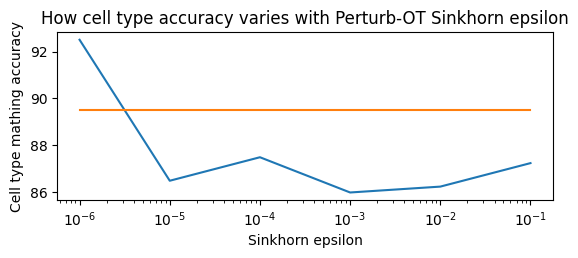

In [26]:
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
line, = ax.plot(eps_list, pairing_accs)
line, = ax.plot(eps_list, [baseline_acc_no_pairings]*len(eps_list))
ax.set_xscale('log')
plt.xlabel("Sinkhorn epsilon")
plt.ylabel("Cell type mathing accuracy")
plt.title("How cell type accuracy varies with Perturb-OT Sinkhorn epsilon")

### Repeating across 3 donors and including 1e-7

In [44]:
n_samples = 1000
pairs = [(i,i+8) for i in range(6)]
eps_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

In [45]:
pairing_acc_lists = []
no_pairing_accs = []
for pair in pairs:
    # Set up train data

    a1_full, a2_full = sample_equal_cell_types(all_adatas[pair[0]], all_adatas[pair[1]], n_samples)
    a1_train, a1_test, a2_train, a2_test = test_train_split_adata(a1_full, a2_full, train_ratio=0.8)
    X_dict, Y_dict, X_full_dict, Y_full_dict, X_index_dict, Y_index_dict = create_label_to_sample_dicts(a1_train, a2_train)
    sorted_train_index = concat_index([Y_index_dict[k] for k in Y_dict])
    X_stacked = np.vstack([X_dict[k] for k in X_dict])  
    Y_stacked = np.vstack([Y_dict[k] for k in Y_dict])
    
    # OT map
    T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict))
    
    # Set up test data
    X_test_dict, Y_test_dict, X_test_full_dict, Y_test_full_dict, X_test_index_dict, Y_test_index_dict = create_label_to_sample_dicts(a1_test, a2_test)
    sorted_test_index = concat_index([Y_test_index_dict[k] for k in Y_test_dict])
    X_test_stacked = np.vstack([X_test_dict[k] for k in X_test_dict])  
    Y_test_stacked = np.vstack([Y_test_dict[k] for k in Y_test_dict])
    
    result = fit_mlp(X_stacked.astype(np.float32),
                     Y_stacked.astype(np.float32),
                     epochs=500,
                     batch_size=128,
                     lr=1e-3)
    model = result['model']
    
    baseline_acc_no_pairings = cell_type_knn_acc(model, X_test_stacked, Y_stacked, all_adatas[pair[1]], sorted_train_index, sorted_test_index)
    
    pairing_accs = []
    for eps in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]:
        T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), eps)

        Y_paired_dict = {}
        for i in range(len(T_dict)):
            pairings_i = np.argmax(T_dict[i], axis=1)
            Y_paired_dict[i] = np.zeros(Y_dict[i].shape)
            for j in range(len(pairings_i)):
                Y_paired_dict[i][j] = Y_dict[i][pairings_i[j]]

        X_paired_stacked = np.vstack([X_dict[k] for k in X_dict])  
        Y_paired_stacked = np.vstack([Y_paired_dict[k] for k in Y_paired_dict])

        result = fit_mlp(X_paired_stacked.astype(np.float32), 
                         Y_paired_stacked.astype(np.float32), 
                         epochs=500, 
                         batch_size=128, 
                         lr=1e-3)
        model_paired = result['model']

        pairing_acc = cell_type_knn_acc(model_paired, X_test_stacked, Y_paired_stacked, all_adatas[pair[1]], sorted_train_index, sorted_test_index)
        print(eps, pairing_acc)
        pairing_accs.append(pairing_acc)
    no_pairing_accs.append(baseline_acc_no_pairings)
    pairing_acc_lists.append(pairing_accs)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: True
The outer loop of Gromov Wasserstein has converged: True
The final regularized GW cost is: 2.528
Done running LEGWOT with ott
Epoch 001 | loss 16.880585
Epoch 100 | loss 7.239873
Epoch 200 | loss 6.199588
Epoch 300 | loss 5.632954
Epoch 400 | loss 5.283287
Epoch 500 | loss 4.950657
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: nan
Done running LEGWOT with ott
Epoch 001 | loss 17.771561
Epoch 100 | loss 1.151070
Epoch 200 | loss 0.489191
Epoch 300 | loss 0.31877

IndexError: index 1750 is out of bounds for axis 0 with size 1750

In [46]:
pairing_acc_lists

[[94.5, 94.5, 88.5, 88.5, 84.5, 86.5, 79.0, 80.5],
 [97.0, 97.0, 97.0, 89.5, 82.0, 82.5, 84.5, 85.5],
 [91.5, 91.5, 91.5, 81.0, 78.0, 83.0, 76.0, 78.0],
 [98.0, 98.0, 98.0, 90.0, 89.5, 81.0, 81.5, 87.5],
 [92.5, 92.5, 92.5, 88.5, 87.0, 80.5, 83.0, 87.5]]

In [61]:
no_pairing_accs

[82.5, 83.5, 76.0, 81.5, 85.5]

In [47]:
eps_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

In [48]:
ot_acc_means = np.array(pairing_acc_lists).mean(axis=0)
ot_acc_stds = np.array(pairing_acc_lists).std(axis=0)

In [49]:
baseline_means = np.mean(no_pairing_accs)
baseline_stds = np.std(no_pairing_accs)

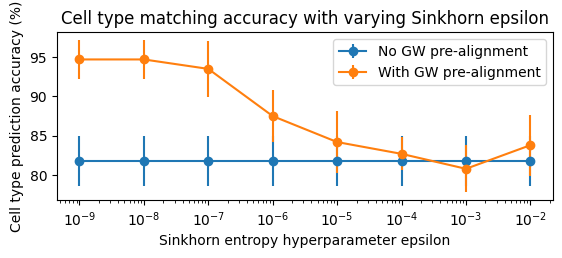

In [58]:
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
plt.errorbar(eps_list, [baseline_means]*len(eps_list), yerr=[baseline_stds]*len(eps_list), fmt='-o', label='No GW pre-alignment')
plt.errorbar(eps_list, ot_acc_means, yerr=ot_acc_stds, fmt='-o', label='With GW pre-alignment')
plt.legend(loc="upper right")
plt.xlabel('Sinkhorn entropy hyperparameter epsilon')
plt.ylabel('Cell type prediction accuracy (%)')
plt.title('Cell type matching accuracy with varying Sinkhorn epsilon')
ax.set_xscale('log')

### Conclusions

Using a Perturb-OT "get_coupling_egw_labels_ott" Sinkhorn entropy parameter of ~1e-8 when generating point-to-point pairings of mouse and human cells results in significantly higher cell type prediction accuracy.